<a href="https://colab.research.google.com/github/maksimovicd501-wq/Dijabetes/blob/main/Diabetes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.Diabetes Dataset - Exploratory Data Analysis

We work with the **Diabetes Dataset for Beginners** (Pima Indians Diabetes dataset) from Kaggle.

The goal of this introductory section is to:
1. Load the data
2. Clean it (handle missing/invalid values)
3. Display basic statistics and several visualizations

This is the preparation step for further work.



### 1.1 Importing Libraries

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 1.2 Loading the Data

The dataset is loaded directly from GitHub, so no manual file upload is needed each session.

In [41]:
url = "https://raw.githubusercontent.com/maksimovicd501-wq/Dijabetes/main/data/diabetes.csv"

df = pd.read_csv(url)
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [42]:
df.shape

(768, 9)

### 1.3 Basic Data Overview

Before cleaning, let's look at column types, check for missing values (NaN), and review basic statistics.

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [44]:
print("Number of missing (NaN) values per column:")
df.isnull().sum()

Number of missing (NaN) values per column:


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


The dataset contains no missing (NaN) values.

In [45]:
df.describe() #basic statistics

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 1.4 Data Cleaning

Although no NaN values were found in the previous step, the data is not
fully clean. Several columns contain zeros that are biologically impossible
— a value of 0 cannot occur for Glucose, BloodPressure, SkinThickness,
Insulin, or BMI in a living person. These zeros represent missing
measurements that were encoded as 0 instead of NaN.

(The Pregnancies column can legitimately be 0 — it simply means the person
has never been pregnant — so we leave those zeros untouched.)

In [46]:
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Number of zeros per column (potentially missing data):")
for col in cols_with_invalid_zeros:
    n_zeros = (df[col] == 0).sum()
    print(f"  {col:25s}: {n_zeros} zeros out of {len(df)} ({n_zeros/len(df)*100:.1f}%)")

Number of zeros per column (potentially missing data):
  Glucose                  : 5 zeros out of 768 (0.7%)
  BloodPressure            : 35 zeros out of 768 (4.6%)
  SkinThickness            : 227 zeros out of 768 (29.6%)
  Insulin                  : 374 zeros out of 768 (48.7%)
  BMI                      : 11 zeros out of 768 (1.4%)


In [47]:
# Replace zeros with NaN so we can properly impute missing values
df_clean = df.copy()
df_clean[cols_with_invalid_zeros] = df_clean[cols_with_invalid_zeros].replace(0, np.nan)

print("Number of NaN values after replacement:")
df_clean.isnull().sum()

Number of NaN values after replacement:


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


### Imputing Missing Values

Since Insulin has 48.7% and SkinThickness has 29.6% missing values,
deleting those rows would reduce the dataset by more than half.
Therefore, we impute missing values using the per-class median,
which is more robust to outliers than the mean.

In [48]:
for col in cols_with_invalid_zeros:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda x: x.fillna(x.median()))

print("Check — number of NaN values after imputation:")
print(df_clean.isnull().sum().sum(), "total NaN values remaining")
df_clean.head()

Check — number of NaN values after imputation:
0 total NaN values remaining


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,169.5,33.6,0.627,50,1
1,1,85.0,66.0,29.0,102.5,26.6,0.351,31,0
2,8,183.0,64.0,32.0,169.5,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


### Checking for Duplicates

In [49]:
n_duplicates = df_clean.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates}")

Number of duplicate rows: 0


The data is now clean — no duplicate rows were found, and all missing
values have been imputed. The dataset is ready for further analysis.

### 1.5 Basic Statistics After Cleaning

In [50]:
df_clean.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 1.6 Distribution of the Target Variable (Outcome)

`Outcome` is the target variable: 1 = the person has diabetes, 0 = they do not. It is important to check whether the dataset is balanced (roughly equal number of examples per class) or imbalanced, as this affects the choice of evaluation metrics and models in later steps.

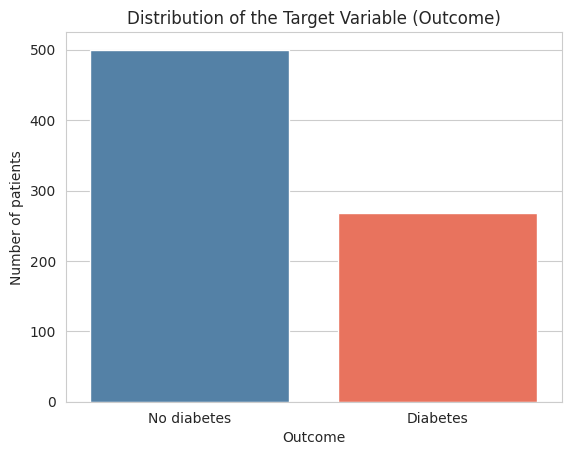

In [51]:

sns.countplot(data=df_clean, x="Outcome", hue="Outcome", palette=["steelblue", "tomato"], legend=False)
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.title("Distribution of the Target Variable (Outcome)")
plt.ylabel("Number of patients")
plt.show()

The dataset is imbalanced — 500 patients (65%) do not have diabetes
and 268 (35%) do.

### 1.7 Distribution of Key Numerical Features

Let's look at histograms of the most important columns to get a feel for the range and shape of their distributions.

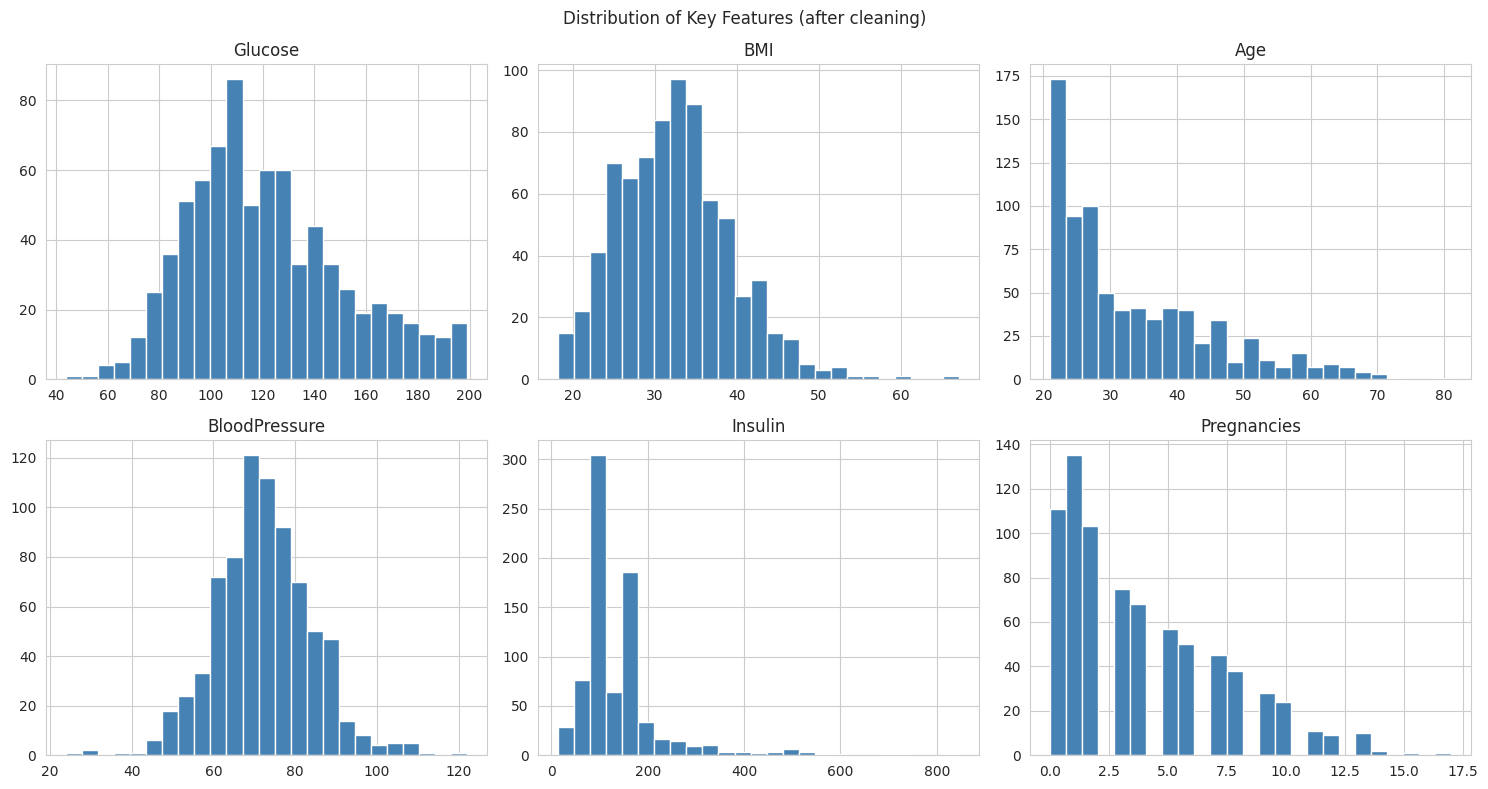

In [52]:
cols_to_plot = ["Glucose", "BMI", "Age", "BloodPressure", "Insulin", "Pregnancies"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    ax.hist(df_clean[col], bins=25, color="steelblue")
    ax.set_title(col)

plt.suptitle("Distribution of Key Features (after cleaning)")
plt.tight_layout()
plt.show()

Glucose, BloodPressure and BMI approximately follow a normal distribution.
The remaining features (Age, Insulin, Pregnancies) are right-skewed.
This is relevant for Naive Bayes and QDA, which assume Gaussian-distributed
features — the skewed features may slightly violate this assumption.

### 1.8 Feature Comparison Between Classes
We compare feature distributions between diabetic and non-diabetic
patients to identify which features are most useful for classification.

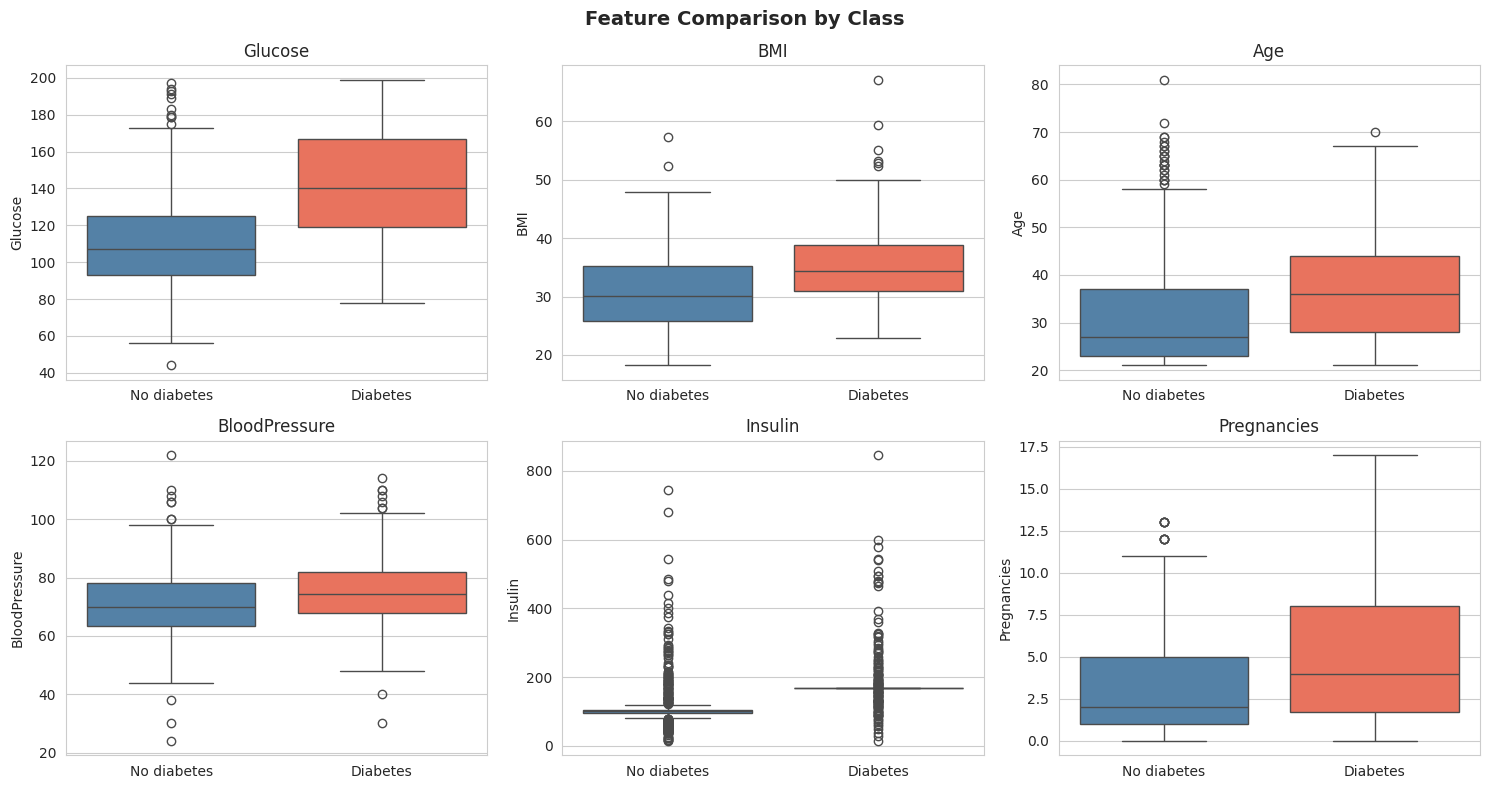

In [53]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, cols_to_plot):
    sns.boxplot(data=df_clean, x="Outcome", y=col, hue="Outcome", ax=ax, palette=["steelblue", "tomato"], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["No diabetes", "Diabetes"])
    ax.set_title(col)
    ax.set_xlabel("")

plt.suptitle("Feature Comparison by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Glucose shows the clearest separation between classes and is the
strongest predictor of diabetes. BMI and Age also show a noticeable
difference between classes. BloodPressure and Pregnancies show
little separation, making them weaker predictors. Insulin has a
large number of outliers, which may affect model performance.

### 1.9 Feature Correlations

The correlation matrix shows the relationships between features.
This is particularly relevant for Naive Bayes, which assumes that
all features are independent — high correlations between features
would indicate a violation of this assumption.

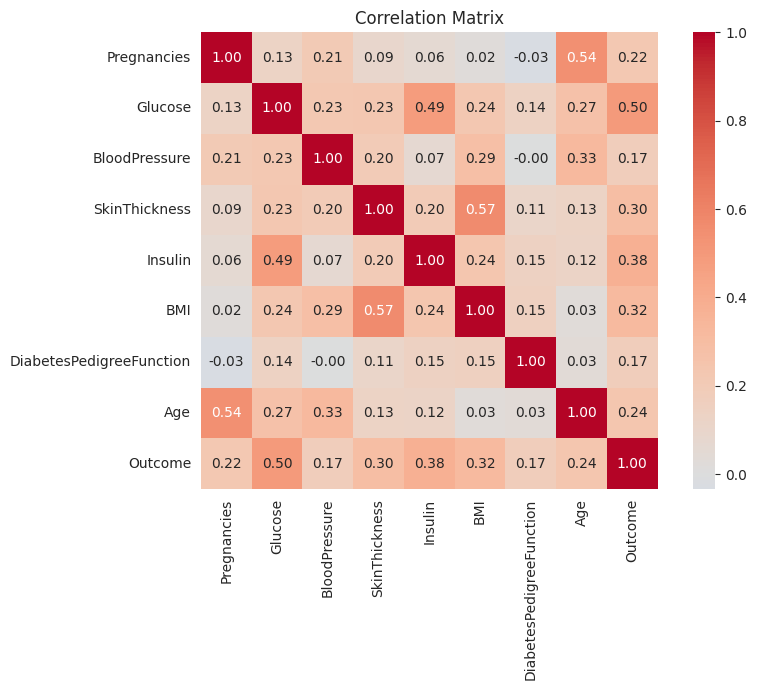

Correlation of each feature with Outcome (sorted):
Glucose                     0.495990
Insulin                     0.377081
BMI                         0.315577
SkinThickness               0.295138
Age                         0.238356
Pregnancies                 0.221898
BloodPressure               0.174469
DiabetesPedigreeFunction    0.173844
Name: Outcome, dtype: float64


In [54]:
plt.figure(figsize=(9, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

print("Correlation of each feature with Outcome (sorted):")
print(corr["Outcome"].drop("Outcome").sort_values(ascending=False))

Glucose has the strongest correlation with Outcome (0.50), followed
by Insulin (0.38) and BMI (0.32). BloodPressure and
DiabetesPedigreeFunction show the weakest correlation with Outcome.

Among the features themselves, the strongest correlations are between
Age and Pregnancies (0.54) and SkinThickness and BMI (0.57). This
suggests that the independence assumption of Naive Bayes is not fully
satisfied, which may slightly affect its performance compared to
QDA and KNN which do not make this assumption.

### 1.10 Summary

- The dataset contains 8 numerical features and a binary target variable `Outcome`.
- The dataset is imbalanced (65% no diabetes, 35% diabetes),
  so accuracy alone will not be sufficient for model evaluation.
- Zeros in columns `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` were identified as missing values and imputed with the per-class median.
- From the boxplots and correlation matrix, `Glucose`, `Insulin` and `BMI` show the strongest association with diabetes — these are the most promising predictors for the classification models.
- The cleaned data (`df_clean`) is now ready for the next steps: standardization, train/test split, and training the classification models (Naive Bayes, QDA, KNN, Weighted KNN).